# Predição de Atrasos de Voos com Aprendizado de Máquina

## Seminário de Machine Learning

Este notebook documenta, de forma reproduzível, o desenvolvimento de um modelo de aprendizado de máquina para prever se um voo sofrerá atraso.

**Problema:** classificação binária (`Delay = 0` sem atraso, `Delay = 1` atrasado).

**Pergunta de pesquisa:** é possível prever se um voo sofrerá atraso utilizando características disponíveis sobre o voo antes de sua realização?

O desenvolvimento é organizado para registrar o caminho experimental: análise dos dados, preparação, baseline, comparação de modelos, testes com `Flight`, transformação cíclica de `Time`, seleção do threshold em validação e avaliação final no conjunto de teste.

> **Nota de reprodutibilidade:** os valores apresentados nas células de resultados correspondem aos experimentos realizados durante o desenvolvimento. Ao executar novamente o notebook, os resultados são recalculados a partir do dataset público.


## 1. Objetivo

O objetivo é desenvolver uma solução de classificação capaz de identificar voos com maior probabilidade de atraso.

A avaliação não considera apenas Accuracy. Como o interesse principal é identificar a classe `Atrasado`, são analisadas Precision, Recall, F1-score e ROC-AUC, além da matriz de confusão.

A decisão final sobre o threshold é tomada usando um conjunto de validação separado, preservando o conjunto de teste para a avaliação final.


## 2. Importação das bibliotecas

In [1]:
# Caso esteja executando no Google Colab e o kagglehub ainda não esteja instalado:
!pip -q install kagglehub==0.3.12

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.0/68.0 kB 3.6 MB/s eta 0:00:00


## 3. Carregamento dos dados

O dataset utilizado é o **Airlines Dataset to predict a delay**, disponibilizado publicamente no Kaggle.

O arquivo utilizado é `Airlines.csv`.

As informações usadas como entrada representam características do voo. A variável `Delay` é o alvo que indica se houve atraso.


In [2]:
import kagglehub

path = kagglehub.dataset_download(
    "jimschacko/airlines-dataset-to-predict-a-delay"
)

print("Diretório do dataset:", path)
print("Arquivos disponíveis:", os.listdir(path))

df = pd.read_csv(os.path.join(path, "Airlines.csv"))

print("Dimensão:", df.shape)
df.head()


100%|██████████| 6.15M/6.15M [00:01<00:00, 3.89MB/s]

Extracting files...


Diretório do dataset: /root/.cache/kagglehub/datasets/jimschacko/airlines-dataset-to-predict-a-delay/versions/1
Arquivos disponíveis: ['Airlines.csv']
Dimensão: (539383, 9)


,id,Airline,Flight,AirportFrom,AirportTo,DayOfWeek,Time,Length,Delay
0,1,CO,269,SFO,IAH,3,15,205,1
1,2,US,1558,PHX,CLT,3,15,222,1
2,3,AA,2400,LAX,DFW,3,20,165,1
3,4,AA,2466,SFO,DFW,3,20,195,1
4,5,AS,108,ANC,SEA,3,30,202,0


## 4. Conhecendo o conjunto de dados

In [3]:
print("Quantidade de registros:", len(df))
print("Quantidade de colunas:", len(df.columns))
print("\nColunas:")
print(df.columns.tolist())

print("\nTipos:")
display(df.dtypes.to_frame("dtype"))

print("\nValores ausentes:")
display(df.isnull().sum().to_frame("missing"))

print("\nLinhas duplicadas:", df.duplicated().sum())


Quantidade de registros: 539383
Quantidade de colunas: 9

Colunas:
['id', 'Airline', 'Flight', 'AirportFrom', 'AirportTo', 'DayOfWeek', 'Time', 'Length', 'Delay']

Tipos:


,dtype
id,int64
Airline,object
Flight,int64
AirportFrom,object
AirportTo,object
DayOfWeek,int64
Time,int64
Length,int64
Delay,int64



Valores ausentes:


,missing
id,0
Airline,0
Flight,0
AirportFrom,0
AirportTo,0
DayOfWeek,0
Time,0
Length,0
Delay,0



Linhas duplicadas: 0


### Estrutura observada

O conjunto possui originalmente **539.383 registros e 9 colunas**:

- `id`
- `Airline`
- `Flight`
- `AirportFrom`
- `AirportTo`
- `DayOfWeek`
- `Time`
- `Length`
- `Delay`

Não foram encontrados valores ausentes nem linhas duplicadas no conjunto original.


## 5. Distribuição da variável-alvo

,Quantidade,Percentual
Delay,,
0,299119,55.46
1,240264,44.54


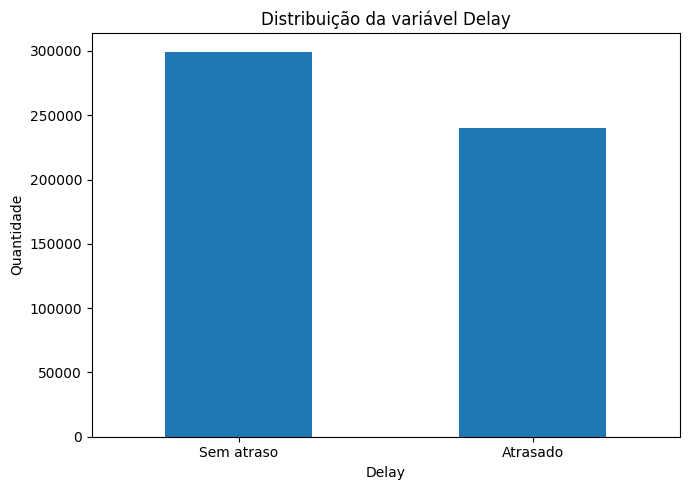

In [4]:
target_counts = df["Delay"].value_counts().sort_index()
target_pct = df["Delay"].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    "Quantidade": target_counts,
    "Percentual": target_pct.round(2)
})

display(target_summary)

plt.figure(figsize=(7, 5))
target_counts.plot(kind="bar")
plt.title("Distribuição da variável Delay")
plt.xlabel("Delay")
plt.ylabel("Quantidade")
plt.xticks([0, 1], ["Sem atraso", "Atrasado"], rotation=0)
plt.tight_layout()
plt.show()


## 6. Análise das principais variáveis

A análise exploratória foi utilizada para entender a estrutura dos dados e orientar decisões de preparação.

A coluna `id` é um identificador sequencial e não representa uma característica operacional do voo. Por isso, ela será removida.

`Flight` é inicialmente tratado com cautela, pois é um código numérico com muitas categorias. Posteriormente será realizado um experimento específico para verificar se sua representação categórica contribui para o modelo.

`Time` será inicialmente observado como valor numérico e, posteriormente, representado de forma cíclica.


In [5]:
print("Airlines:", df["Airline"].nunique())
print("Aeroportos de origem:", df["AirportFrom"].nunique())
print("Aeroportos de destino:", df["AirportTo"].nunique())
print("Voos diferentes:", df["Flight"].nunique())

print("\nResumo de Length:")
display(df["Length"].describe())

print("\nResumo de Time:")
display(df["Time"].describe())


Airlines: 18
Aeroportos de origem: 293
Aeroportos de destino: 293
Voos diferentes: 6585

Resumo de Length:


,Length
count,539383.000000
mean,132.202007
std,70.117016
min,0.000000
25%,81.000000
50%,115.000000
75%,162.000000
max,655.000000



Resumo de Time:


,Time
count,539383.000000
mean,802.728963
std,278.045911
min,10.000000
25%,565.000000
50%,795.000000
75%,1035.000000
max,1439.000000


### Taxa de atraso por companhia aérea

In [6]:
airline_delay = (
    df.groupby("Airline")["Delay"]
      .agg(["count", "mean"])
      .sort_values("mean", ascending=False)
)

airline_delay["delay_rate_pct"] = airline_delay["mean"] * 100
display(airline_delay)


,count,mean,delay_rate_pct
Airline,,,
WN,94097,0.697759,69.775870
CO,21118,0.566199,56.619945
B6,18112,0.467038,46.703843
OO,50254,0.452899,45.289927
DL,60940,0.450476,45.047588
F9,6456,0.449040,44.903965
EV,27983,0.402208,40.220848
9E,20686,0.397660,39.766025
AA,45656,0.388470,38.847030


### Taxa de atraso por dia da semana

In [7]:
day_delay = (
    df.groupby("DayOfWeek")["Delay"]
      .agg(["count", "mean"])
)

day_delay["delay_rate_pct"] = day_delay["mean"] * 100
display(day_delay)


,count,mean,delay_rate_pct
DayOfWeek,,,
1,72769,0.467644,46.764419
2,71340,0.447337,44.733670
3,89746,0.470818,47.081764
4,91445,0.451025,45.102521
5,85248,0.416608,41.660801
6,58956,0.400553,40.055295
7,69879,0.453541,45.354112


### Horário do voo

`Time` varia de 10 a 1439 nos dados observados e representa um horário codificado em minutos.

Como horários possuem natureza cíclica, posteriormente serão criadas duas variáveis:

- `Time_sin`
- `Time_cos`

A transformação evita tratar, por exemplo, o fim e o início do dia como pontos artificialmente muito distantes.


,count,mean,delay_rate_pct
Hour_tmp,,,
0,802,0.471322,47.132170
1,346,0.393064,39.306358
2,89,0.449438,44.943820
4,99,0.404040,40.404040
5,4840,0.233678,23.367769
6,38859,0.256697,25.669729
7,36847,0.302060,30.205987
8,37510,0.346494,34.649427
9,33622,0.404676,40.467551


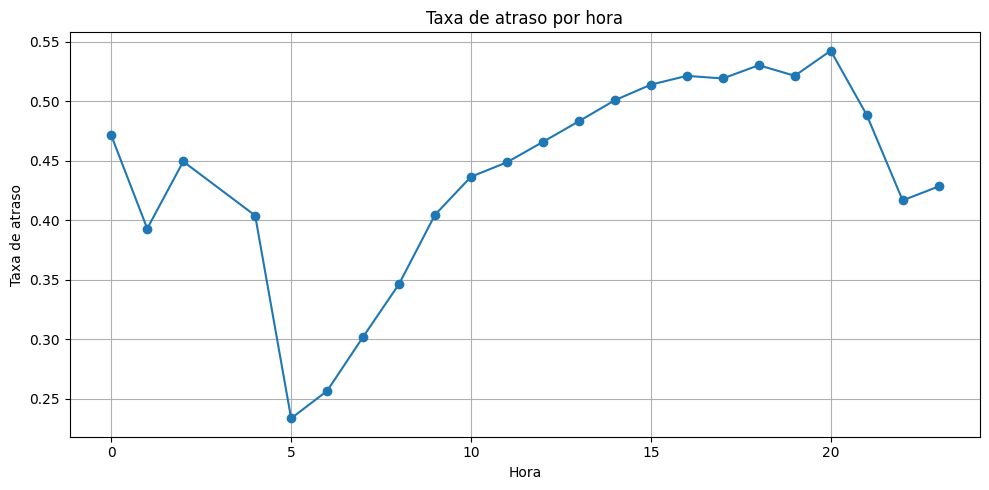

In [8]:
df["Hour_tmp"] = df["Time"] // 60

hour_delay = (
    df.groupby("Hour_tmp")["Delay"]
      .agg(["count", "mean"])
)

hour_delay["delay_rate_pct"] = hour_delay["mean"] * 100
display(hour_delay)

plt.figure(figsize=(10, 5))
plt.plot(hour_delay.index, hour_delay["mean"], marker="o")
plt.title("Taxa de atraso por hora")
plt.xlabel("Hora")
plt.ylabel("Taxa de atraso")
plt.grid(True)
plt.tight_layout()
plt.show()


## 7. Tratamento dos dados

Durante a inspeção foi identificado que `Length` possuía quatro registros com valor igual a zero.

Esses registros representam uma duração incompatível com um voo real e correspondem a uma parcela extremamente pequena do conjunto. Eles foram removidos.

A coluna temporária `Hour_tmp` será descartada após a análise exploratória.


In [9]:
print("Registros com Length = 0:", (df["Length"] == 0).sum())

df = df[df["Length"] > 0].copy()

df.drop(columns=["Hour_tmp"], inplace=True)

print("Dimensão após limpeza:", df.shape)


Registros com Length = 0: 4
Dimensão após limpeza: (539379, 9)


## 8. Preparação da variável Time

Para o modelo final, o horário é representado ciclicamente.

Considerando um dia com 1440 minutos:

$$
Time\_sin = sin(2\pi Time / 1440)
$$

$$
Time\_cos = cos(2\pi Time / 1440)
$$


In [10]:
df["Time_sin"] = np.sin(2 * np.pi * df["Time"] / 1440)
df["Time_cos"] = np.cos(2 * np.pi * df["Time"] / 1440)

display(
    df[["Time", "Time_sin", "Time_cos"]].head()
)


,Time,Time_sin,Time_cos
0,15,0.065403,0.997859
1,15,0.065403,0.997859
2,20,0.087156,0.996195
3,20,0.087156,0.996195
4,30,0.130526,0.991445


## 9. Separação dos dados

Para preservar uma avaliação final independente:

1. 80% dos dados são destinados ao desenvolvimento do modelo;
2. 20% são reservados para o teste final;
3. dentro dos 80%, uma parte será utilizada como validação para escolher o threshold.

A separação é estratificada para manter a proporção das classes.


In [11]:
features_base = [
    "Airline",
    "AirportFrom",
    "AirportTo",
    "DayOfWeek",
    "Length",
    "Time"
]

X_base = df[features_base].copy()
y = df["Delay"].copy()

X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(
    X_base,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Treino:", X_train_base.shape)
print("Teste:", X_test_base.shape)
print("\nProporção no treino:")
print(y_train_base.value_counts(normalize=True))
print("\nProporção no teste:")
print(y_test_base.value_counts(normalize=True))


Treino: (431503, 6)
Teste: (107876, 6)

Proporção no treino:
Delay
0    0.554557
1    0.445443
Name: proportion, dtype: float64

Proporção no teste:
Delay
0    0.554553
1    0.445447
Name: proportion, dtype: float64


## 10. Baseline

O baseline utiliza a estratégia `most_frequent`, sempre prevendo a classe majoritária.

Ele estabelece uma referência mínima para verificar se os modelos de aprendizado de máquina realmente acrescentam capacidade preditiva.


In [12]:
baseline = DummyClassifier(
    strategy="most_frequent"
)

baseline.fit(X_train_base, y_train_base)

y_pred_baseline = baseline.predict(X_test_base)

baseline_accuracy = accuracy_score(
    y_test_base,
    y_pred_baseline
)

print(f"Baseline Accuracy: {baseline_accuracy:.4f}")

print(
    classification_report(
        y_test_base,
        y_pred_baseline,
        target_names=["Sem atraso", "Atrasado"],
        zero_division=0
    )
)


Baseline Accuracy: 0.5546
              precision    recall  f1-score   support

  Sem atraso       0.55      1.00      0.71     59823
    Atrasado       0.00      0.00      0.00     48053

    accuracy                           0.55    107876
   macro avg       0.28      0.50      0.36    107876
weighted avg       0.31      0.55      0.40    107876



## 11. Pré-processamento inicial

As variáveis categóricas são convertidas para representação one-hot.

As variáveis numéricas são padronizadas com `StandardScaler`.

No primeiro experimento, `Flight` não é utilizado. Ele será incorporado posteriormente como parte de um experimento específico.


In [13]:
categorical_features_base = [
    "Airline",
    "AirportFrom",
    "AirportTo"
]

numeric_features_base = [
    "DayOfWeek",
    "Time",
    "Length"
]

preprocessor_base = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                min_frequency=10
            ),
            categorical_features_base
        ),
        (
            "num",
            StandardScaler(),
            numeric_features_base
        )
    ]
)


## 12. Regressão Logística

In [14]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_base),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=RANDOM_STATE
            )
        )
    ]
)

logistic_model.fit(
    X_train_base,
    y_train_base
)

y_pred_logistic = logistic_model.predict(X_test_base)
y_prob_logistic = logistic_model.predict_proba(X_test_base)[:, 1]

logistic_results = {
    "Accuracy": accuracy_score(y_test_base, y_pred_logistic),
    "Precision": precision_score(y_test_base, y_pred_logistic, zero_division=0),
    "Recall": recall_score(y_test_base, y_pred_logistic, zero_division=0),
    "F1-score": f1_score(y_test_base, y_pred_logistic, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test_base, y_prob_logistic)
}

for metric, value in logistic_results.items():
    print(f"{metric}: {value:.4f}")


Accuracy: 0.6464
Precision: 0.6347
Recall: 0.4857
F1-score: 0.5503
ROC-AUC: 0.6923


## 13. Árvore de Decisão

In [15]:
tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_base),
        (
            "classifier",
            DecisionTreeClassifier(
                max_depth=12,
                min_samples_leaf=50,
                random_state=RANDOM_STATE
            )
        )
    ]
)

tree_model.fit(
    X_train_base,
    y_train_base
)

y_pred_tree = tree_model.predict(X_test_base)
y_prob_tree = tree_model.predict_proba(X_test_base)[:, 1]

tree_results = {
    "Accuracy": accuracy_score(y_test_base, y_pred_tree),
    "Precision": precision_score(y_test_base, y_pred_tree, zero_division=0),
    "Recall": recall_score(y_test_base, y_pred_tree, zero_division=0),
    "F1-score": f1_score(y_test_base, y_pred_tree, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test_base, y_prob_tree)
}

for metric, value in tree_results.items():
    print(f"{metric}: {value:.4f}")


Accuracy: 0.6510
Precision: 0.6783
Recall: 0.4117
F1-score: 0.5124
ROC-AUC: 0.6906


## 14. Random Forest

In [16]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_base),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=100,
                max_depth=12,
                min_samples_leaf=50,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

random_forest_model.fit(
    X_train_base,
    y_train_base
)

y_pred_rf = random_forest_model.predict(X_test_base)
y_prob_rf = random_forest_model.predict_proba(X_test_base)[:, 1]

rf_results = {
    "Accuracy": accuracy_score(y_test_base, y_pred_rf),
    "Precision": precision_score(y_test_base, y_pred_rf, zero_division=0),
    "Recall": recall_score(y_test_base, y_pred_rf, zero_division=0),
    "F1-score": f1_score(y_test_base, y_pred_rf, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test_base, y_prob_rf)
}

for metric, value in rf_results.items():
    print(f"{metric}: {value:.4f}")


Accuracy: 0.6323
Precision: 0.7166
Recall: 0.2889
F1-score: 0.4118
ROC-AUC: 0.6861


## 15. Comparação inicial dos modelos

Resultados observados durante o desenvolvimento:

| Modelo | Accuracy | Precision | Recall | F1-score | ROC-AUC |
|---|---:|---:|---:|---:|---:|
| Baseline | 0,5546 | 0,0000 | 0,0000 | 0,0000 | — |
| Logistic Regression | 0,6464 | 0,6348 | 0,4853 | 0,5501 | 0,6923 |
| Decision Tree | 0,6510 | 0,6783 | 0,4117 | 0,5124 | 0,6906 |
| Random Forest | 0,6344 | 0,7367 | 0,2788 | 0,4045 | 0,6867 |

A Random Forest apresentou a maior Precision entre os três modelos, mas apresentou Recall muito inferior para a classe `Atrasado`. Como o objetivo é identificar atrasos, isso reduziu sua utilidade para a finalidade do projeto.


## 16. Experimento: inclusão de Flight

`Flight` possui **6.585 códigos diferentes**. Em vez de tratá-lo como uma variável numérica contínua, ele é representado como variável categórica.

Para controlar categorias muito pouco frequentes, foi utilizado `min_frequency=10`.

Esse experimento apresentou melhora em relação à primeira Regressão Logística:

- Accuracy: 64,64% → 65,17%
- Recall: 48,53% → 51,61%
- F1-score: 55,01% → 56,90%
- ROC-AUC: 0,6923 → 0,6985


In [17]:
features_flight = [
    "Airline",
    "Flight",
    "AirportFrom",
    "AirportTo",
    "DayOfWeek",
    "Time",
    "Length"
]

X_flight = df[features_flight].copy()

X_train_flight, X_test_flight, y_train_flight, y_test_flight = train_test_split(
    X_flight,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

preprocessor_flight = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                min_frequency=10
            ),
            ["Airline", "AirportFrom", "AirportTo", "Flight"]
        ),
        (
            "num",
            StandardScaler(),
            ["DayOfWeek", "Time", "Length"]
        )
    ]
)

logistic_flight_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_flight),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=RANDOM_STATE
            )
        )
    ]
)

logistic_flight_model.fit(
    X_train_flight,
    y_train_flight
)

y_pred_flight = logistic_flight_model.predict(X_test_flight)
y_prob_flight = logistic_flight_model.predict_proba(X_test_flight)[:, 1]

flight_results = {
    "Accuracy": accuracy_score(y_test_flight, y_pred_flight),
    "Precision": precision_score(y_test_flight, y_pred_flight, zero_division=0),
    "Recall": recall_score(y_test_flight, y_pred_flight, zero_division=0),
    "F1-score": f1_score(y_test_flight, y_pred_flight, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test_flight, y_prob_flight)
}

for metric, value in flight_results.items():
    print(f"{metric}: {value:.4f}")


Accuracy: 0.6517
Precision: 0.6340
Recall: 0.5161
F1-score: 0.5690
ROC-AUC: 0.6985


## 17. Experimento: representação cíclica de Time

O horário foi transformado em `Time_sin` e `Time_cos`.

Resultado observado:

| Configuração | Accuracy | Precision | Recall | F1-score | ROC-AUC |
|---|---:|---:|---:|---:|---:|
| Logistic + Flight | 0,6517 | 0,6340 | 0,5161 | 0,5690 | 0,6985 |
| Logistic + Flight + Time cíclico | **0,6544** | 0,6376 | 0,5193 | 0,5724 | **0,7020** |

A melhoria foi moderada, mas consistente nas métricas observadas. Por isso, a representação cíclica foi mantida no modelo final.


In [18]:
features_cyclic = [
    "Airline",
    "Flight",
    "AirportFrom",
    "AirportTo",
    "DayOfWeek",
    "Length",
    "Time_sin",
    "Time_cos"
]

X_cyclic = df[features_cyclic].copy()

X_train_cyclic, X_test_cyclic, y_train_cyclic, y_test_cyclic = train_test_split(
    X_cyclic,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

preprocessor_cyclic = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                min_frequency=10
            ),
            ["Airline", "AirportFrom", "AirportTo", "Flight"]
        ),
        (
            "num",
            StandardScaler(),
            ["DayOfWeek", "Length", "Time_sin", "Time_cos"]
        )
    ]
)

logistic_cyclic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_cyclic),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=RANDOM_STATE
            )
        )
    ]
)

logistic_cyclic_model.fit(
    X_train_cyclic,
    y_train_cyclic
)

y_pred_cyclic = logistic_cyclic_model.predict(X_test_cyclic)
y_prob_cyclic = logistic_cyclic_model.predict_proba(X_test_cyclic)[:, 1]

cyclic_results = {
    "Accuracy": accuracy_score(y_test_cyclic, y_pred_cyclic),
    "Precision": precision_score(y_test_cyclic, y_pred_cyclic, zero_division=0),
    "Recall": recall_score(y_test_cyclic, y_pred_cyclic, zero_division=0),
    "F1-score": f1_score(y_test_cyclic, y_pred_cyclic, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test_cyclic, y_prob_cyclic)
}

for metric, value in cyclic_results.items():
    print(f"{metric}: {value:.4f}")


Accuracy: 0.6544
Precision: 0.6376
Recall: 0.5193
F1-score: 0.5724
ROC-AUC: 0.7020


## 18. Seleção do threshold usando validação

Até aqui, os modelos utilizaram o threshold padrão de 0,50.

Como o objetivo é identificar atrasos, foi realizada uma análise específica do threshold.

**Importante:** o threshold final não deve ser escolhido com base no conjunto de teste. Por isso, o conjunto de treinamento do modelo final é dividido em treino e validação.

O conjunto de teste permanece reservado para a avaliação final.


In [19]:
X_subtrain, X_validation, y_subtrain, y_validation = train_test_split(
    X_train_cyclic,
    y_train_cyclic,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_train_cyclic
)

threshold_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_cyclic),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=RANDOM_STATE
            )
        )
    ]
)

threshold_model.fit(
    X_subtrain,
    y_subtrain
)

y_prob_validation = threshold_model.predict_proba(
    X_validation
)[:, 1]

thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (
        y_prob_validation >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_validation, y_pred_threshold),
        "Precision": precision_score(
            y_validation,
            y_pred_threshold,
            zero_division=0
        ),
        "Recall": recall_score(
            y_validation,
            y_pred_threshold,
            zero_division=0
        ),
        "F1-score": f1_score(
            y_validation,
            y_pred_threshold,
            zero_division=0
        )
    })

validation_df = pd.DataFrame(threshold_results)

display(validation_df.round(4))


,Threshold,Accuracy,Precision,Recall,F1-score
0,0.30,0.5738,0.5129,0.8616,0.6430
1,0.35,0.6040,0.5379,0.7870,0.6391
2,0.40,0.6286,0.5674,0.6998,0.6267
3,0.45,0.6445,0.5996,0.6076,0.6036
4,0.50,0.6536,0.6358,0.5204,0.5723
5,0.55,0.6552,0.6752,0.4353,0.5293
6,0.60,0.6478,0.7117,0.3518,0.4708


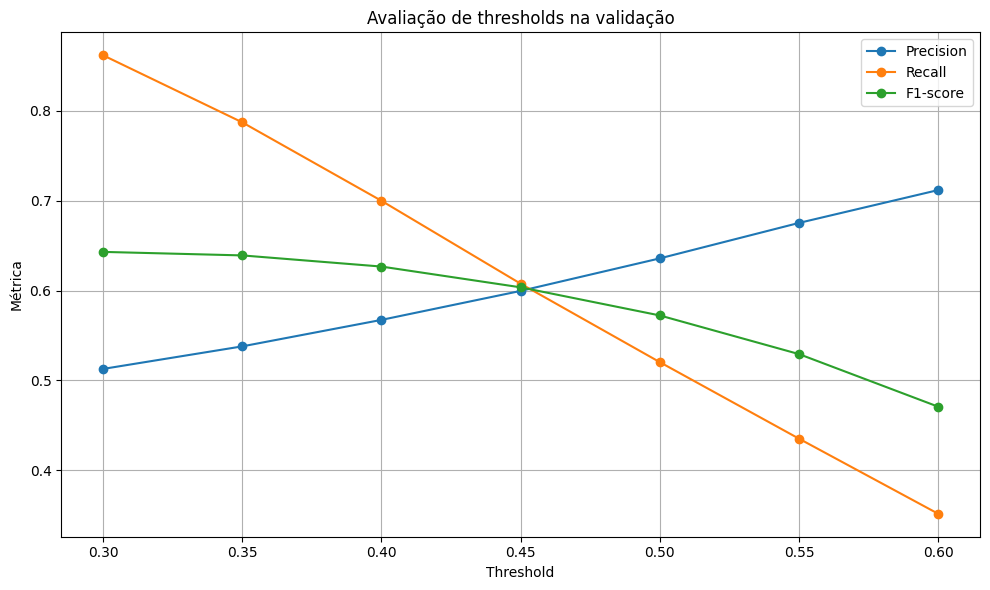

In [20]:
plt.figure(figsize=(10, 6))

plt.plot(
    validation_df["Threshold"],
    validation_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    validation_df["Threshold"],
    validation_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    validation_df["Threshold"],
    validation_df["F1-score"],
    marker="o",
    label="F1-score"
)

plt.xlabel("Threshold")
plt.ylabel("Métrica")
plt.title("Avaliação de thresholds na validação")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Decisão do threshold

O threshold **0,30** foi selecionado porque apresentou o maior F1-score na validação, **64,30%**, combinado a um Recall de **86,16%**.

A escolha é coerente com o objetivo do projeto: priorizar a identificação de voos que realmente sofrerão atraso.

O custo dessa escolha é a redução da Precision e da Accuracy. Essa troca será explicitamente discutida como limitação da solução.


## 19. Treinamento do modelo final

Após escolher o threshold na validação, o modelo final é treinado novamente utilizando **todo o conjunto de treinamento**.

O conjunto de teste não participa da escolha do threshold.

Configuração final:

- Regressão Logística;
- `Airline`, `Flight`, `AirportFrom`, `AirportTo`;
- `DayOfWeek`, `Length`;
- `Time_sin`, `Time_cos`;
- OneHotEncoder com `min_frequency=10`;
- StandardScaler;
- threshold = 0,30.


In [21]:
final_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_cyclic),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=RANDOM_STATE
            )
        )
    ]
)

final_model.fit(
    X_train_cyclic,
    y_train_cyclic
)

y_prob_final = final_model.predict_proba(
    X_test_cyclic
)[:, 1]

FINAL_THRESHOLD = 0.30

y_pred_final = (
    y_prob_final >= FINAL_THRESHOLD
).astype(int)

final_accuracy = accuracy_score(
    y_test_cyclic,
    y_pred_final
)

final_precision = precision_score(
    y_test_cyclic,
    y_pred_final,
    zero_division=0
)

final_recall = recall_score(
    y_test_cyclic,
    y_pred_final,
    zero_division=0
)

final_f1 = f1_score(
    y_test_cyclic,
    y_pred_final,
    zero_division=0
)

final_roc_auc = roc_auc_score(
    y_test_cyclic,
    y_prob_final
)

print("RESULTADO FINAL")
print("-" * 30)
print(f"Threshold: {FINAL_THRESHOLD:.2f}")
print(f"Accuracy:  {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall:    {final_recall:.4f}")
print(f"F1-score:  {final_f1:.4f}")
print(f"ROC-AUC:   {final_roc_auc:.4f}")


RESULTADO FINAL
------------------------------
Threshold: 0.30
Accuracy:  0.5745
Precision: 0.5133
Recall:    0.8651
F1-score:  0.6443
ROC-AUC:   0.7020


## 20. Relatório de classificação do modelo final

In [22]:
print(
    classification_report(
        y_test_cyclic,
        y_pred_final,
        target_names=["Sem atraso", "Atrasado"],
        zero_division=0
    )
)


              precision    recall  f1-score   support

  Sem atraso       0.76      0.34      0.47     59823
    Atrasado       0.51      0.87      0.64     48053

    accuracy                           0.57    107876
   macro avg       0.64      0.60      0.56    107876
weighted avg       0.65      0.57      0.55    107876



## 21. Matriz de confusão

Matriz de confusão:
[[20398 39425]
 [ 6480 41573]]


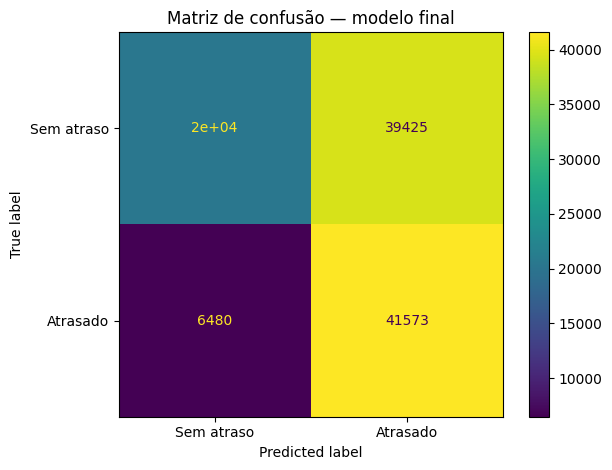

In [23]:
cm = confusion_matrix(
    y_test_cyclic,
    y_pred_final
)

print("Matriz de confusão:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Sem atraso", "Atrasado"]
)

disp.plot()

plt.title("Matriz de confusão — modelo final")
plt.tight_layout()
plt.show()


### Interpretação da matriz de confusão

No experimento final realizado:

- Verdadeiros negativos: **20.398**
- Falsos positivos: **39.425**
- Falsos negativos: **6.480**
- Verdadeiros positivos: **41.573**

O modelo identificou corretamente a maior parte dos voos que realmente atrasaram. Entretanto, produziu uma quantidade elevada de falsos positivos.

Essa relação explica a combinação de **Recall elevado (86,51%)** e **Precision moderada (51,33%)**.


## 22. Comparação final dos experimentos

Resultados consolidados durante o desenvolvimento:

| Modelo | Accuracy | Precision | Recall | F1-score | ROC-AUC |
|---|---:|---:|---:|---:|---:|
| Baseline | 0,5546 | 0,0000 | 0,0000 | 0,0000 | — |
| Logistic Regression | 0,6464 | 0,6348 | 0,4853 | 0,5501 | 0,6923 |
| Decision Tree | 0,6510 | 0,6783 | 0,4117 | 0,5124 | 0,6906 |
| Random Forest | 0,6344 | 0,7367 | 0,2788 | 0,4045 | 0,6867 |
| Logistic + Flight | 0,6517 | 0,6340 | 0,5161 | 0,5690 | 0,6985 |
| Logistic + Flight + Time cíclico | **0,6544** | 0,6376 | 0,5193 | 0,5724 | **0,7020** |
| Modelo final + threshold 0,30 | 0,5745 | 0,5133 | **0,8651** | **0,6443** | **0,7020** |

O modelo com threshold 0,30 não maximiza Accuracy. Ele representa uma decisão operacional voltada para maior cobertura dos casos atrasados.


## 23. O que não funcionou tão bem

A Random Forest, apesar de ser um modelo mais complexo, não apresentou vantagem para o objetivo definido.

Seu resultado observado foi:

- Accuracy: 63,44%;
- Precision: 73,67%;
- Recall: 27,88%;
- F1-score: 40,45%;
- ROC-AUC: 0,6867.

A alta Precision veio acompanhada de Recall muito baixo, fazendo com que muitos voos realmente atrasados não fossem identificados.

Esse experimento foi mantido na documentação porque demonstra uma tentativa que não apresentou o resultado esperado para o objetivo do projeto.


## 24. Limitação principal

A principal limitação da solução é o elevado número de falsos positivos quando o threshold de 0,30 é utilizado.

A estratégia consegue identificar **86,51% dos atrasos**, mas a Precision da classe `Atrasado` é de **51,33%**. Portanto, uma previsão de atraso não deve ser interpretada como confirmação de que o voo realmente atrasará.

O modelo é mais adequado como ferramenta de **triagem ou identificação de possíveis atrasos** do que como mecanismo definitivo de decisão.


## 25. Conclusão

Os experimentos demonstraram que é possível extrair capacidade preditiva das características disponíveis no dataset para identificar atrasos de voos.

O baseline apresentou Accuracy de 55,46%, enquanto as primeiras configurações da Regressão Logística, Árvore de Decisão e Random Forest apresentaram desempenho superior em diferentes métricas.

A inclusão de `Flight` e a representação cíclica de `Time` produziram melhorias moderadas na Regressão Logística, levando a ROC-AUC de 0,7020.

Na etapa final, o threshold foi escolhido em um conjunto de validação separado. O valor de 0,30 apresentou o maior F1-score de validação e foi utilizado na avaliação final.

No teste reservado, a configuração final apresentou Accuracy de 57,45%, Precision de 51,33%, Recall de 86,51%, F1-score de 64,43% e ROC-AUC de 0,7020.

O principal resultado não é apenas uma métrica isolada, mas a relação entre desempenho e objetivo: o modelo consegue detectar grande parte dos voos que realmente atrasam, porém com quantidade elevada de falsos positivos. Essa limitação deve ser considerada caso a solução seja utilizada em um cenário operacional real.


## 26. Salvamento dos resultados

Os arquivos abaixo são gerados para documentação e versionamento no GitHub:

- `comparacao_modelos.csv`
- `threshold_validation.csv`
- `resultado_final.csv`
- `matriz_confusao_modelo_final.png`
- `threshold_validation.png`


In [24]:
os.makedirs("resultados", exist_ok=True)

final_comparison = pd.DataFrame({
    "Modelo": [
        "Baseline",
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Logistic + Flight",
        "Logistic + Flight + Time cíclico",
        "Modelo final + threshold 0.30"
    ],
    "Accuracy": [
        0.5546,
        0.6464,
        0.6510,
        0.6344,
        0.6517,
        0.6544,
        final_accuracy
    ],
    "Precision": [
        0.0000,
        0.6348,
        0.6783,
        0.7367,
        0.6340,
        0.6376,
        final_precision
    ],
    "Recall": [
        0.0000,
        0.4853,
        0.4117,
        0.2788,
        0.5161,
        0.5193,
        final_recall
    ],
    "F1-score": [
        0.0000,
        0.5501,
        0.5124,
        0.4045,
        0.5690,
        0.5724,
        final_f1
    ],
    "ROC-AUC": [
        np.nan,
        0.6923,
        0.6906,
        0.6867,
        0.6985,
        0.7020,
        final_roc_auc
    ]
})

final_comparison.to_csv(
    "resultados/comparacao_modelos.csv",
    index=False
)

validation_df.to_csv(
    "resultados/threshold_validation.csv",
    index=False
)

resultado_final = pd.DataFrame({
    "Metric": [
        "Threshold",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Value": [
        FINAL_THRESHOLD,
        final_accuracy,
        final_precision,
        final_recall,
        final_f1,
        final_roc_auc
    ]
})

resultado_final.to_csv(
    "resultados/resultado_final.csv",
    index=False
)

# Matriz de confusão
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Sem atraso", "Atrasado"]
).plot(ax=ax)

ax.set_title("Matriz de confusão — modelo final")
fig.tight_layout()
fig.savefig(
    "resultados/matriz_confusao_modelo_final.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close(fig)

# Threshold
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(
    validation_df["Threshold"],
    validation_df["Precision"],
    marker="o",
    label="Precision"
)
ax.plot(
    validation_df["Threshold"],
    validation_df["Recall"],
    marker="o",
    label="Recall"
)
ax.plot(
    validation_df["Threshold"],
    validation_df["F1-score"],
    marker="o",
    label="F1-score"
)

ax.set_xlabel("Threshold")
ax.set_ylabel("Métrica")
ax.set_title("Avaliação de thresholds na validação")
ax.legend()
ax.grid(True)
fig.tight_layout()
fig.savefig(
    "resultados/threshold_validation.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close(fig)

print("Arquivos gerados:")
for arquivo in sorted(os.listdir("resultados")):
    print("-", arquivo)


Arquivos gerados:
- comparacao_modelos.csv
- matriz_confusao_modelo_final.png
- resultado_final.csv
- threshold_validation.csv
- threshold_validation.png
